# Probability of Default (PD) Model

## Project Goal
The objective of this project is to develop a credit risk model that estimates the Probability of Default (PD) for borrowers based on their financial characteristics.

Credit institutions use PD models to identify high-risk borrowers and support lending decisions. In this project, we simulate borrower data and build a predictive model to classify borrowers into defaulters and non-defaulters.

## Approach
To achieve this objective, we follow a structured credit risk modeling workflow:

1. Generate a synthetic borrower dataset representing loan applicants.
2. Perform exploratory data analysis to understand borrower characteristics.
3. Engineer relevant financial features such as the Loan-to-Income ratio.
4. Train a Logistic Regression model to estimate default probability.
5. Evaluate model performance using metrics such as Accuracy and ROC-AUC.
6. Validate the model using cross-validation to test stability.

This notebook demonstrates the end-to-end process of developing a simplified Probability of Default model similar to those used in credit risk analytics.

In [3]:
import pandas as pd
import numpy as np

# Set random seed so results are reproducible
np.random.seed(42)

# Number of borrowers in dataset
n = 1000

# Generate synthetic borrower characteristics
income = np.random.normal(50000,15000,n)      # Annual income distribution
loan_amount = np.random.normal(20000,8000,n)  # Loan size distribution
age = np.random.randint(21,65,n)              # Borrower age

# Create an important credit risk feature
# Loan-to-income ratio is commonly used in credit analysis
loan_income_ratio = loan_amount/income

# Create a synthetic risk score that influences default probability
# Assumptions:
# Higher loan-to-income ratio -> higher default risk
# Younger borrowers -> slightly higher risk
prob_default = 0.3*loan_income_ratio + 0.002*(50-age)

# Convert risk score into probability using logistic transformation
# This ensures probability values stay between 0 and 1
prob_default = 1/(1+np.exp(-prob_default))

# Simulate whether default occurs
# Each borrower defaults with probability = prob_default
default = np.random.binomial(1,prob_default)

# Create final dataset
data = pd.DataFrame({
'income':income,
'loan_amount':loan_amount,
'age':age,
'loan_income_ratio':loan_income_ratio,
'default':default
})

# View first few rows
data.head()

,income,loan_amount,age,loan_income_ratio,default
0,57450.712295,31194.843493,50,0.542984,0
1,47926.035482,27397.069463,51,0.571653,1
2,59715.328072,20477.042959,58,0.342911,1
3,72845.447846,14824.505778,31,0.203506,1
4,46487.699379,25585.786509,55,0.550378,0


In [4]:
data.describe()

,income,loan_amount,age,loan_income_ratio,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50289.980837,20566.689898,42.522000,0.474225,0.534000
std,14688.239073,7979.635018,12.594767,0.607069,0.499092
min,1380.989899,-3523.109077,21.000000,-0.088555,0.000000
25%,40286.145418,15150.066488,32.000000,0.284667,0.000000
50%,50379.509184,20504.617059,42.500000,0.408187,1.000000
75%,59719.158132,25831.057416,53.000000,0.568758,1.000000
max,107790.972360,45544.860543,64.000000,17.603350,1.000000


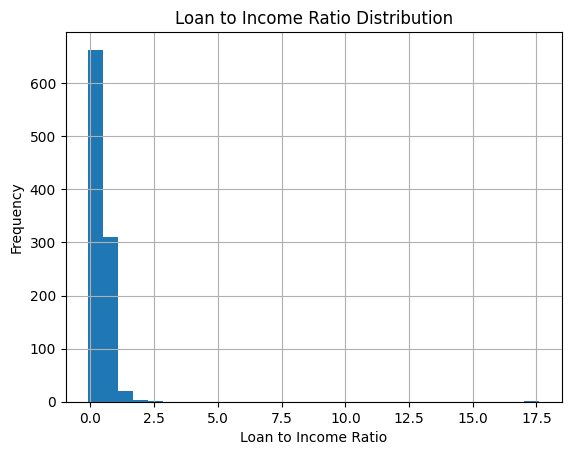

In [5]:
import matplotlib.pyplot as plt

data['loan_income_ratio'].hist(bins=30)
plt.title("Loan to Income Ratio Distribution")
plt.xlabel("Loan to Income Ratio")
plt.ylabel("Frequency")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select the input features used to predict default
# These are borrower characteristics
X = data[['income','loan_amount','age','loan_income_ratio']]

# Target variable we want to predict
# 1 = default, 0 = no default
y = data['default']

# Split dataset into training and testing sets
# Training data is used to build the model
# Test data is used to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create logistic regression model with more iterations
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Predict default probability for each borrower in the test dataset
# [:,1] selects the probability of class "1" (default)
y_prob = model.predict_proba(X_test)[:,1]

# Convert probabilities into predicted classes (0 or 1)
# Default threshold = 0.5
y_pred = model.predict(X_test)

# Calculate model accuracy
# Accuracy = percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)

# Calculate ROC-AUC score
# This measures how well the model separates defaulters vs non-defaulters
auc = roc_auc_score(y_test, y_prob)

# Create confusion matrix
# Shows correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print("Model Accuracy:", accuracy)
print("ROC-AUC Score:", auc)
print("Confusion Matrix:")
print(cm)

Model Accuracy: 0.5366666666666666
ROC-AUC Score: 0.5408035714285715
Confusion Matrix:
[[  5 135]
 [  4 156]]


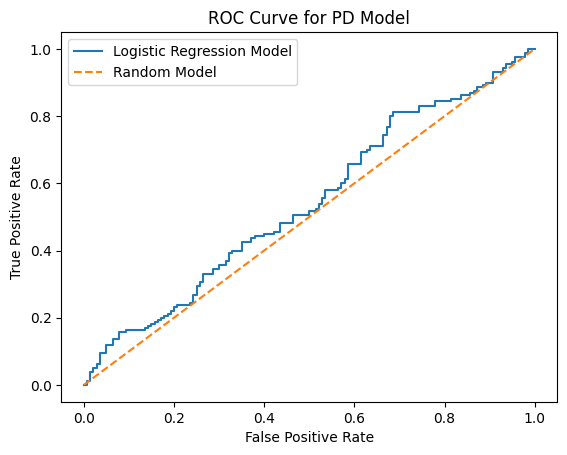

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label="Logistic Regression Model")
plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

# Label the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for PD Model")
plt.legend()

plt.show()

In [17]:
# Show model coefficients (feature importance)

features = X.columns
coefficients = model.coef_[0]

for feature, coef in zip(features, coefficients):
    print(feature, ":", coef)

income : 9.541059925323493e-06
loan_amount : -2.265944773567633e-05
age : 0.0033613915625136533
loan_income_ratio : 1.1524398593555392


In [18]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation
# The dataset is split into 5 parts
# Model trains on 4 parts and tests on the remaining part
# This repeats 5 times for stability

scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

# Print ROC-AUC scores for each fold
print("Cross-validation AUC scores:", scores)

# Print average performance
print("Average AUC:", scores.mean())

Cross-validation AUC scores: [0.52860297 0.47884635 0.48969953 0.47623354 0.54858808]
Average AUC: 0.5043940942896386


# Business Interpretation

The objective of this model was to estimate the Probability of Default (PD) for borrowers based on financial characteristics.

Key observations:
- The model uses borrower income, loan amount, age, and loan-to-income ratio to estimate default risk.
- Logistic regression was selected because it is widely used in credit scoring models due to its interpretability.

Model performance:
- The ROC-AUC score indicates the model's ability to distinguish between defaulters and non-defaulters.
- Cross-validation was applied to assess model stability across different data samples.

Limitations:
- The dataset used in this project is synthetic and simplified.
- Real-world credit models use larger datasets and additional borrower features such as credit history, employment stability, and payment behavior.

Conclusion:
This project demonstrates the core workflow of credit risk modeling, including data preparation, feature engineering, model development, evaluation, and interpretation.